In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set figure size for better readability
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

# Load the dataset
file_path = 'cartoon_popularity_data.csv' # Fill here with the path to your dataset

# Check if the file exists
try:
    with open(file_path, 'r') as f:
        pass
except FileNotFoundError:
    print(f"File {file_path} not found. Please check the path and try again.")
    exit()

# Read the dataset
df = pd.read_csv(file_path)

# Display the first few rows
print(f"Dataset shape: {df.shape}")
df.head(20)

Dataset shape: (10000, 5)


,Character,Country,Popularity_Score,Avg_Episodes_Watched_Per_Year,Merchandise_Revenue_MillionUSD
0,Shinchan,Canada,74.06677446676758,80,3.949924724368964
1,Paw Patrol,France,80.58192518328079,48,22.31606244865129
2,SpongeBob SquarePants,Russia,37.853437720835345,127.5,258.92694939230086
3,Motu Patlu,UK,83.41104266407503,50,27.430804382862224
4,Mr Bean,Egypt,76.83135775923722,9,40.715313915210565
5,Mr Bean,Russia,74.49889820916066,100,89.88446547664522
6,Shinchan,China,42.215996679968406,53,47.33693889068305
7,Shinchan,France,29.350012864742613,5,87.70944109744121
8,Motu Patlu,Australia,53.937903011962575,72,60.295513861562675
9,Motu Patlu,Saudi Arabia,48.59904633166138,73,13.710754985476516


In [11]:
#Part 1: Exploratory Data Analysis (EDA)
#Task 1.1: Basic Data Exploration

# Display shape of dataset
print("Shape of Dataset:")
print(df.shape)

print("________________________")

# Display column names
print("Column Names:")
print(df.columns)

print("________________________")

# Check data types
print("Data Types:")
print(df.dtypes)

print("________________________")

# Generate basic statistics
print("Basic Statistics:")
print(df.describe())

print("________________________")

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Shape of Dataset:
(10000, 5)
________________________
Column Names:
Index(['Character', 'Country', 'Popularity_Score',
       'Avg_Episodes_Watched_Per_Year', 'Merchandise_Revenue_MillionUSD'],
      dtype='object')
________________________
Data Types:
Character                          object
Country                            object
Popularity_Score                  float64
Avg_Episodes_Watched_Per_Year     float64
Merchandise_Revenue_MillionUSD    float64
dtype: object
________________________
Basic Statistics:
       Popularity_Score  Avg_Episodes_Watched_Per_Year  \
count       9487.000000                    9856.000000   
mean          50.799874                      80.732802   
std           31.862795                     123.350453   
min          -19.860206                     -10.000000   
25%           24.319758                      31.000000   
50%           50.463176                      59.000000   
75%           76.638101                      87.000000   
max          149

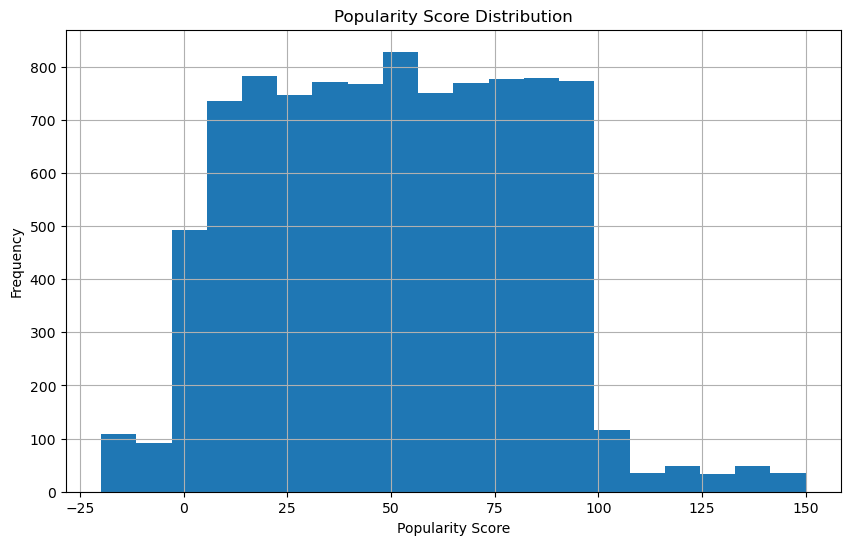

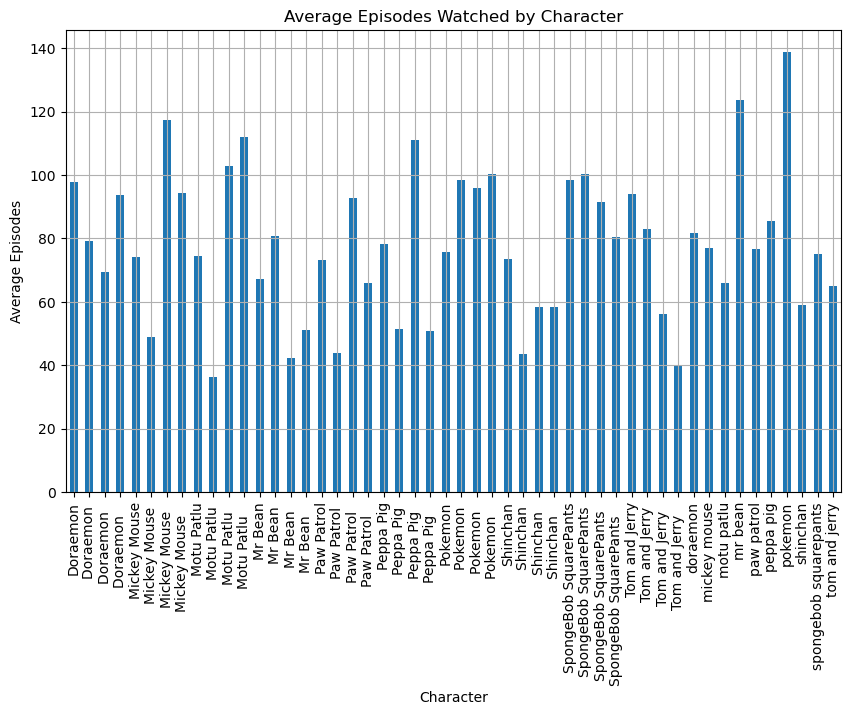

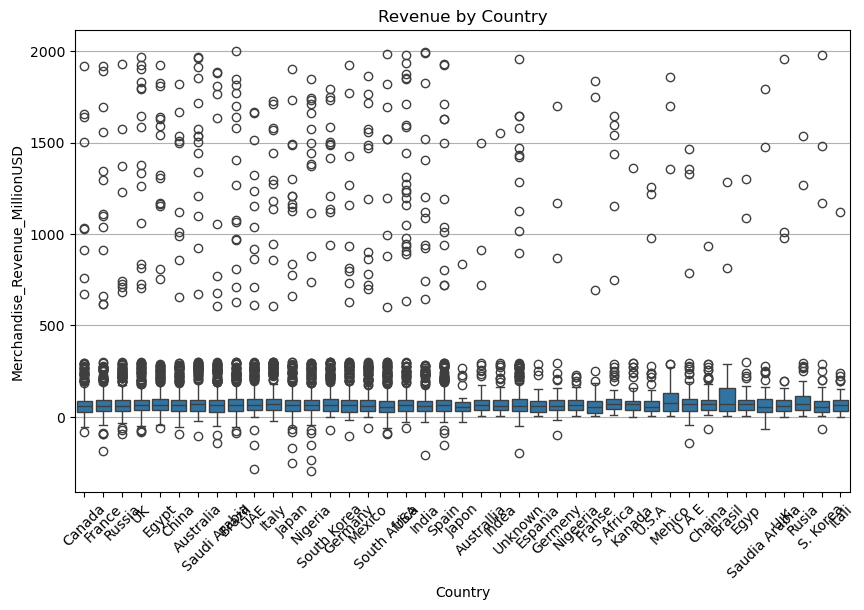

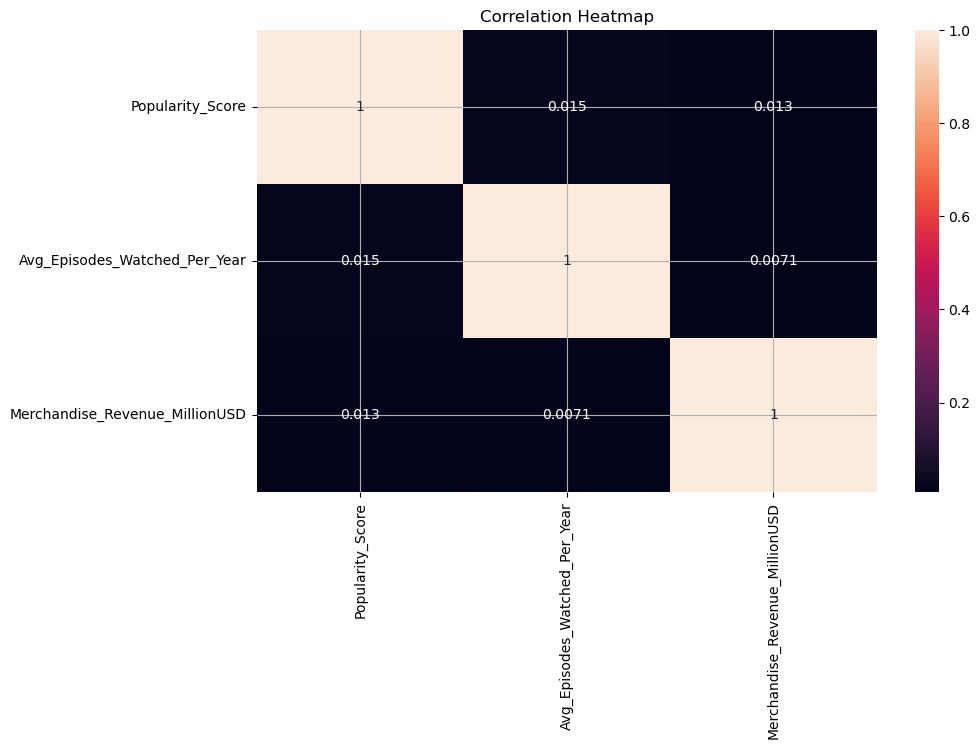

In [14]:
# TASK 1.2 : DATA VISUALIZATION

import seaborn as sns

# 1. Histogram of Popularity Scores
plt.hist(df['Popularity_Score'], bins=20)
plt.title('Popularity Score Distribution')
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.show()


# 2. Average Episodes Watched by Character
avg_episodes = df.groupby('Character')[
    'Avg_Episodes_Watched_Per_Year'
].mean()

avg_episodes.plot(kind='bar')
plt.title('Average Episodes Watched by Character')
plt.xlabel('Character')
plt.ylabel('Average Episodes')
plt.show()


# 3. Box Plot of Revenue by Country
sns.boxplot(
    x='Country',
    y='Merchandise_Revenue_MillionUSD',
    data=df
)

plt.xticks(rotation=45)
plt.title('Revenue by Country')
plt.show()


# 4. Correlation Heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True)

plt.title('Correlation Heatmap')
plt.show()

In [25]:
# TASK 1.3 : IDENTIFYING DATA ISSUES
# Data Quality Issues Found

# 1. MISSING VALUES 

#Some columns contain missing or null values.
# Category: Missing Data
# Effect on Analysis: Missing values can affect statistical calculations and reduce the accuracy of analysis and machine learning models.

# 2. INCORRECT DATA TYPES

# Numerical columns were initially stored as object datatype instead of numeric datatype.
# Category: Data Type Inconsistency
# Effect on Analysis:Numerical operations, graphs, and statistical analysis may not work correctly if numerical data is stored as text.

# 3. OUTLIERS

# Some numerical columns contain unusually high or low values.
# Category: Outliers
# Effect on Analysis:Outliers can distort averages, correlations, and overall analysis results.

# 4. DUPLICATE ROWS

# Duplicate records may exist in the dataset.
# Category: Duplicate Data
# Effect on Analysis:Duplicate rows can bias the analysis and produce inaccurate results.

# 5. INCONSISTENT ROWS 

# Some categorical values may contain inconsistencies such as different spellings, capitalization, or extra spaces.
# Category: Inconsistent Categorical Data
# Effect on Analysis:Inconsistent data can lead to incorrect grouping and inaccurate analysis results.

#*************************************************************************************************************************************************
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

print("************************")

# Check duplicate rows

print("Duplicate Rows:")
print(df.duplicated().sum())

print("************************")

# Statistical summary to identify outliers
print("Statistical Summary:\n")
print(df.describe())

Missing Values:

Character                         0
Country                           0
Popularity_Score                  0
Avg_Episodes_Watched_Per_Year     0
Merchandise_Revenue_MillionUSD    0
dtype: int64
************************
Duplicate Rows:
0
************************
Statistical Summary:

       Popularity_Score  Avg_Episodes_Watched_Per_Year  \
count      10000.000000                   10000.000000   
mean          50.799874                      80.732802   
std           31.034670                     122.459020   
min          -19.860206                     -10.000000   
25%           25.816413                      31.500000   
50%           50.799874                      60.000000   
75%           75.254013                      86.000000   
max          149.947947                     999.000000   

       Merchandise_Revenue_MillionUSD  
count                    10000.000000  
mean                       116.306742  
std                        238.097789  
min              

In [23]:
# TASK 2.1 : HANDLING MISSING VALUES

# Fill categorical columns
df['Character'] = df['Character'].fillna(
    df['Character'].mode()[0]
)

df['Country'] = df['Country'].fillna(
    df['Country'].mode()[0]
)

# Fill numerical columns
df['Popularity_Score'] = df['Popularity_Score'].fillna(
    df['Popularity_Score'].mean()
)

df['Avg_Episodes_Watched_Per_Year'] = df[
    'Avg_Episodes_Watched_Per_Year'
].fillna(
    df['Avg_Episodes_Watched_Per_Year'].mean()
)

df['Merchandise_Revenue_MillionUSD'] = df[
    'Merchandise_Revenue_MillionUSD'
].fillna(
    df['Merchandise_Revenue_MillionUSD'].mean()
)

# Check missing values again
print(df.isnull().sum())

Character                         0
Country                           0
Popularity_Score                  0
Avg_Episodes_Watched_Per_Year     0
Merchandise_Revenue_MillionUSD    0
dtype: int64


In [24]:
# Approach for Handling Missing Values

# 1. Categorical Columns

# Missing values in Character and Country columns were replaced using the mode (most frequent value).
# Reason:Mode is suitable for categorical data because it preserves the most common category in the dataset.

# 2. Numerical Columns

# Missing values in numerical columns were replaced using the mean value.
# Reason:Mean helps maintain the overall distribution of numerical data and is a commonly used technique for handling missing numerical values.

In [27]:
# TASK 2.2 : HANDLING INCONSISTENT DATA

# Remove extra spaces and standardize character names
df['Character'] = df['Character'].str.strip().str.title()

# Remove extra spaces and standardize country names
df['Country'] = df['Country'].str.strip().str.title()

# Convert numerical columns into proper numeric datatype
df['Popularity_Score'] = pd.to_numeric(
    df['Popularity_Score'],
    errors='coerce'
)

df['Avg_Episodes_Watched_Per_Year'] = pd.to_numeric(
    df['Avg_Episodes_Watched_Per_Year'],
    errors='coerce'
)

df['Merchandise_Revenue_MillionUSD'] = pd.to_numeric(
    df['Merchandise_Revenue_MillionUSD'],
    errors='coerce'
)

# Display updated data types
print(df.dtypes)

Character                          object
Country                            object
Popularity_Score                  float64
Avg_Episodes_Watched_Per_Year     float64
Merchandise_Revenue_MillionUSD    float64
dtype: object


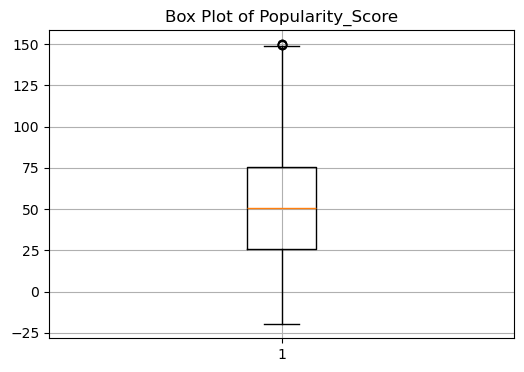

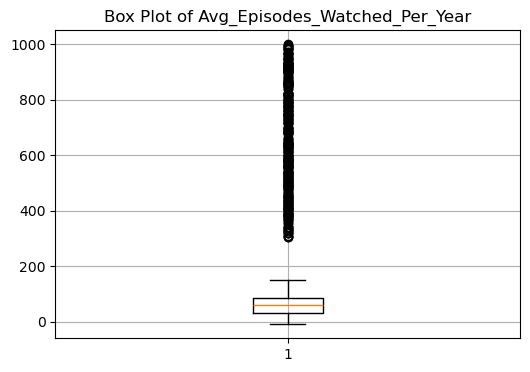

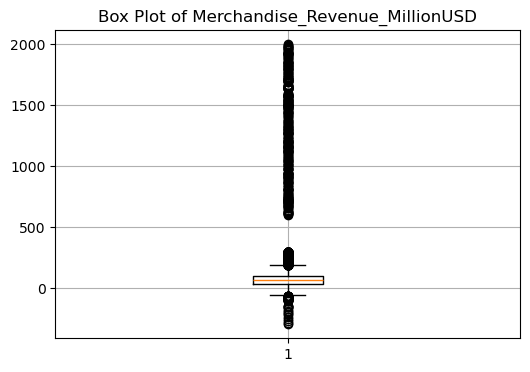

Outliers handled successfully.


In [28]:
# TASK 2.3 : OUTLIER DETECTION AND HANDLING

# Numerical columns
numerical_cols = [
    'Popularity_Score',
    'Avg_Episodes_Watched_Per_Year',
    'Merchandise_Revenue_MillionUSD'
]

# Box plots to visualize outliers
for col in numerical_cols:
    
    plt.figure(figsize=(6,4))
    
    plt.boxplot(df[col].dropna())
    
    plt.title(f'Box Plot of {col}')
    
    plt.show()


# Handling outliers using IQR method
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Capping outliers
    df[col] = np.where(
        df[col] > upper_limit,
        upper_limit,
        np.where(
            df[col] < lower_limit,
            lower_limit,
            df[col]
        )
    )

print("Outliers handled successfully.")

In [29]:
# Approach Used for Outlier Handling
# 1. Outlier Detection
# Box plots were used to visually identify extreme values in numerical columns.

# 2. Statistical Method
# The IQR (Interquartile Range) method was used to detect outliers mathematically.

# 3. Outlier Handling
# Outliers were handled using capping, where extreme values were replaced with upper and lower limits.

# Reason:Capping reduces the impact of outliers while preserving the dataset size and structure.

In [30]:
# TASK 2.4 : DATA TRANSFORMATION

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Numerical columns
numerical_cols = [
    'Popularity_Score',
    'Avg_Episodes_Watched_Per_Year',
    'Merchandise_Revenue_MillionUSD'
]

# Standardize numerical columns
scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Create derived feature
df['Revenue_Per_Episode'] = (
    df['Merchandise_Revenue_MillionUSD'] /
    (df['Avg_Episodes_Watched_Per_Year'] + 1)
)

# Encode categorical columns
encoder = LabelEncoder()

df['Character'] = encoder.fit_transform(df['Character'])

df['Country'] = encoder.fit_transform(df['Country'])

# Display first few rows
print(df.head())

   Character  Country  Popularity_Score  Avg_Episodes_Watched_Per_Year  \
0          7        4          0.749761                       0.428323   
1          4       10          0.959706                      -0.377306   
2          8       26         -0.417183                       1.624179   
3          2       38          1.050872                      -0.326954   
4          3        8          0.838847                      -1.359166   

   Merchandise_Revenue_MillionUSD  Revenue_Per_Episode  
0                       -1.261438            -0.883160  
1                       -0.937192            -1.505060  
2                        1.999031             0.761774  
3                       -0.846894            -1.258300  
4                       -0.612362             1.704956  


In [32]:
# Task 4.1 : SUMMARY OF FINDINGS

# -> 1. Initial State of the Dataset
# The dataset contained missing values, incorrect datatypes, inconsistent categorical data, and outliers in numerical columns.

# -> 2. Issues Identified
# Missing values in some columns
# Numerical columns stored as object datatype
# Outliers in popularity score, episodes watched, and revenue columns
# Inconsistent formatting in categorical columns
# Duplicate rows in the dataset

# -> 3. Methods Used to Address the Issues
# Missing values were handled using mode and mean imputation
# Numerical columns were converted using pd.to_numeric()
# Inconsistent text formatting was corrected using string operations
# Outliers were handled using the IQR capping method
# Numerical features were standardized using StandardScaler()
# Categorical variables were encoded using LabelEncoder()

# -> 4. Final State of the Cleaned Dataset
# The dataset became clean, consistent, and ready for analysis and machine learning applications. Missing values and datatype issues were resolved, and numerical features were transformed properly.

# -> 5. Insights Gained During the Process
# Some countries generated higher merchandise revenue than others
# Outliers significantly affected numerical distributions
# Data preprocessing improves the quality and reliability of analysis
# Feature scaling and encoding help prepare the dataset for machine learning models

In [34]:
# TASK 4.2 : SAVE CLEANED DATASET
df_cleaned = df
df_cleaned.to_csv('cartoon_popularity_cleaned.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
